<a href="https://colab.research.google.com/github/Jorgellamocca/WeatherNext3_Peru/blob/main/WeatherNext_v1.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================

import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta
from google.colab import files

# Estilo general
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False
})


In [2]:
# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

PROJECT_ID = "gee-proyecto-peru-494007"

ASSET = (
    "projects/gcp-public-data-weathernext/assets/"
    "weathernext_3_0_0_0p1deg"
)

# Piura
LAT_PIURA = -5.19
LON_PIURA = -80.63

# Resolución nativa del producto
SCALE = 11132

# Zona horaria de Perú
UTC_OFFSET_HOURS = -5

In [3]:
# ============================================================
# AUTENTICACIÓN E INICIALIZACIÓN DE GOOGLE EARTH ENGINE
# ============================================================

import ee

PROJECT_ID = "gee-proyecto-peru-494007"

# 1. Autenticar
ee.Authenticate()

# 2. Inicializar Earth Engine
ee.Initialize(project=PROJECT_ID)

print("Earth Engine inicializado correctamente.")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine inicializado correctamente.


In [4]:
# ============================================================
# 3. INICIALIZAR EARTH ENGINE
# ============================================================

ee.Initialize(project=PROJECT_ID)

print("Earth Engine inicializado correctamente.")

Earth Engine inicializado correctamente.


In [5]:
# ============================================================
# 4. CARGAR WEATHERNEXT 3
# ============================================================

dataset = ee.ImageCollection(ASSET)

print("Colección cargada:")
print(ASSET)

Colección cargada:
projects/gcp-public-data-weathernext/assets/weathernext_3_0_0_0p1deg


In [6]:
# ============================================================
# 5. PUNTO DE PIURA
# ============================================================

punto_piura = ee.Geometry.Point([
    LON_PIURA,
    LAT_PIURA
])

In [7]:
# ============================================================
# 6. IDENTIFICAR LA ÚLTIMA CORRIDA PRINCIPAL DE 15 DÍAS
#
# Las corridas principales:
#   00 UTC
#   06 UTC
#   12 UTC
#   18 UTC
#
# Tienen 360 horas.
#
# Buscamos directamente las imágenes con forecast_hour = 360
# y obtenemos el último start_time disponible.
# ============================================================

corridas_15d = dataset.filter(
    ee.Filter.eq("forecast_hour", 360)
)

starts_15d = (
    corridas_15d
    .aggregate_array("start_time")
    .distinct()
    .sort()
)

ultimo_start_time = (
    starts_15d
    .get(starts_15d.size().subtract(1))
    .getInfo()
)

print("\n==============================================")
print("ÚLTIMA CORRIDA PRINCIPAL DE 15 DÍAS")
print("==============================================")
print("Start time:", ultimo_start_time)



ÚLTIMA CORRIDA PRINCIPAL DE 15 DÍAS
Start time: 2026-09-24T06:00:00Z


In [8]:
# ============================================================
# 7. EXTRAER LA CORRIDA COMPLETA
# ============================================================

corrida = dataset.filter(
    ee.Filter.eq(
        "start_time",
        ultimo_start_time
    )
)

numero_imagenes = corrida.size().getInfo()

forecast_hours = (
    corrida
    .aggregate_array("forecast_hour")
    .distinct()
    .sort()
    .getInfo()
)

print("Número de horas:", numero_imagenes)
print("Primer forecast_hour:", min(forecast_hours))
print("Último forecast_hour:", max(forecast_hours))


Número de horas: 360
Primer forecast_hour: 1
Último forecast_hour: 360


In [9]:
# ============================================================
# 8. BANDAS
# ============================================================

bands = [

    # Temperatura
    "temperature_2m_mean",
    "temperature_2m_p10",
    "temperature_2m_p25",
    "temperature_2m_p50",
    "temperature_2m_p75",
    "temperature_2m_p90",

    # Precipitación
    "total_precipitation_1hr_mean",
    "total_precipitation_1hr_p10",
    "total_precipitation_1hr_p25",
    "total_precipitation_1hr_p50",
    "total_precipitation_1hr_p75",
    "total_precipitation_1hr_p90"
]

corrida = corrida.select(bands)

In [10]:
# ============================================================
# 9. FUNCIÓN DE EXTRACCIÓN
# ============================================================

def extraer_punto(img):

    valores = img.reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=punto_piura,
        scale=SCALE,
        bestEffort=True
    )

    propiedades = {
        "forecast_hour": img.get("forecast_hour"),
        "start_time": img.get("start_time"),
        "end_time": img.get("end_time")
    }

    valores = valores.combine(
        propiedades,
        overwrite=True
    )

    return ee.Feature(
        None,
        valores
    )

In [11]:
# ============================================================
# 10. EXTRAER TODA LA CORRIDA
# ============================================================

print("\nExtrayendo información para Piura...")

fc = ee.FeatureCollection(
    corrida.map(extraer_punto)
)

resultado = fc.getInfo()

df = pd.DataFrame([
    f["properties"]
    for f in resultado["features"]
])


Extrayendo información para Piura...


In [12]:
# ============================================================
# 11. ORDENAR
# ============================================================

df = df.sort_values(
    "forecast_hour"
).reset_index(drop=True)

In [13]:
# ============================================================
# 12. CONVERTIR FECHAS
# ============================================================

df["start_time"] = pd.to_datetime(
    df["start_time"],
    utc=True
)

df["end_time"] = pd.to_datetime(
    df["end_time"],
    utc=True
)

In [14]:
# ============================================================
# 13. CONVERTIR TEMPERATURA
#
# WeatherNext:
# temperatura = Kelvin
#
# Celsius = Kelvin - 273.15
# ============================================================

temp_cols = [
    "temperature_2m_mean",
    "temperature_2m_p10",
    "temperature_2m_p25",
    "temperature_2m_p50",
    "temperature_2m_p75",
    "temperature_2m_p90"
]

for col in temp_cols:

    df[col.replace(
        "temperature_2m",
        "temp_C"
    )] = df[col] - 273.15

In [15]:
# ============================================================
# 14. CONVERTIR PRECIPITACIÓN
#
# WeatherNext:
# precipitación = metros
#
# 1 m = 1000 mm
# ============================================================

precip_cols = [
    "total_precipitation_1hr_mean",
    "total_precipitation_1hr_p10",
    "total_precipitation_1hr_p25",
    "total_precipitation_1hr_p50",
    "total_precipitation_1hr_p75",
    "total_precipitation_1hr_p90"
]

for col in precip_cols:

    df[col.replace(
        "total_precipitation_1hr_",
        "precip_mm_"
    )] = df[col] * 1000

In [16]:
# ============================================================
# 15. FECHA LOCAL DE PERÚ
#
# Earth Engine entrega UTC.
#
# Perú = UTC-5
#
# Esto es MUY importante para comparar posteriormente
# contra estaciones SENAMHI/PISCO.
# ============================================================

df["fecha_local"] = (
    df["end_time"]
    + pd.Timedelta(hours=UTC_OFFSET_HOURS)
).dt.floor("D")

In [17]:
# ============================================================
# 16. MOSTRAR DATOS HORARIOS
# ============================================================

print("\n==============================================")
print("DATOS HORARIOS")
print("==============================================")

print(
    df[
        [
            "forecast_hour",
            "end_time",
            "fecha_local",
            "temp_C_mean",
            "temp_C_p10",
            "temp_C_p50",
            "temp_C_p90",
            "precip_mm_mean",
            "precip_mm_p50"
        ]
    ].head(10)
)


DATOS HORARIOS
   forecast_hour                  end_time               fecha_local  \
0              1 2026-09-24 07:00:00+00:00 2026-09-24 00:00:00+00:00   
1              2 2026-09-24 08:00:00+00:00 2026-09-24 00:00:00+00:00   
2              3 2026-09-24 09:00:00+00:00 2026-09-24 00:00:00+00:00   
3              4 2026-09-24 10:00:00+00:00 2026-09-24 00:00:00+00:00   
4              5 2026-09-24 11:00:00+00:00 2026-09-24 00:00:00+00:00   
5              6 2026-09-24 12:00:00+00:00 2026-09-24 00:00:00+00:00   
6              7 2026-09-24 13:00:00+00:00 2026-09-24 00:00:00+00:00   
7              8 2026-09-24 14:00:00+00:00 2026-09-24 00:00:00+00:00   
8              9 2026-09-24 15:00:00+00:00 2026-09-24 00:00:00+00:00   
9             10 2026-09-24 16:00:00+00:00 2026-09-24 00:00:00+00:00   

   temp_C_mean  temp_C_p10  temp_C_p50  temp_C_p90  precip_mm_mean  \
0    23.738733   23.607324   23.733209   23.867578        0.001311   
1    23.398676   23.209314   23.407983   23.588922 

In [18]:
# ============================================================
# 17. TEMPERATURA DIARIA
#
# Tmedia = promedio de horas
# Tmin   = mínimo horario
# Tmax   = máximo horario
#
# Se conserva además la información del ensamble.
# ============================================================

daily_temp = (
    df
    .groupby("fecha_local")
    .agg(

        # Temperatura media del ensamble
        tmedia_C=(
            "temp_C_mean",
            "mean"
        ),

        # Incertidumbre de la temperatura media
        tmedia_p10_C=(
            "temp_C_p10",
            "mean"
        ),

        tmedia_p25_C=(
            "temp_C_p25",
            "mean"
        ),

        tmedia_p50_C=(
            "temp_C_p50",
            "mean"
        ),

        tmedia_p75_C=(
            "temp_C_p75",
            "mean"
        ),

        tmedia_p90_C=(
            "temp_C_p90",
            "mean"
        ),

        # Tmin de la trayectoria media
        tmin_C=(
            "temp_C_mean",
            "min"
        ),

        # Tmax de la trayectoria media
        tmax_C=(
            "temp_C_mean",
            "max"
        ),

        horas=(
            "forecast_hour",
            "count"
        )
    )
    .reset_index()
)


In [19]:
# ============================================================
# 18. PRECIPITACIÓN DIARIA
#
# Para precipitación se SUMAN las acumulaciones horarias.
#
# IMPORTANTE:
# La suma de P10/P90 horarios NO equivale matemáticamente
# al P10/P90 exacto de la precipitación diaria del ensamble.
#
# Por eso se denominan:
#   "rango agregado de incertidumbre horaria".
# ============================================================

daily_precip = (
    df
    .groupby("fecha_local")
    .agg(

        precip_mean_mm=(
            "precip_mm_mean",
            "sum"
        ),

        precip_p10_agregado_mm=(
            "precip_mm_p10",
            "sum"
        ),

        precip_p25_agregado_mm=(
            "precip_mm_p25",
            "sum"
        ),

        precip_p50_mm=(
            "precip_mm_p50",
            "sum"
        ),

        precip_p75_agregado_mm=(
            "precip_mm_p75",
            "sum"
        ),

        precip_p90_agregado_mm=(
            "precip_mm_p90",
            "sum"
        ),

        horas=(
            "forecast_hour",
            "count"
        )
    )
    .reset_index()
)


In [20]:
# ============================================================
# 19. UNIR TEMPERATURA + PRECIPITACIÓN
# ============================================================

daily = pd.merge(
    daily_temp,
    daily_precip,
    on=[
        "fecha_local",
        "horas"
    ],
    how="inner"
)


In [21]:
# ============================================================
# 20. CONSERVAR SOLO DÍAS COMPLETOS
#
# Esto elimina automáticamente el primer/último día
# si tienen menos de 24 horas.
# ============================================================

daily_full = daily[
    daily["horas"] == 24
].copy()


daily_full = daily_full.reset_index(
    drop=True
)

In [22]:
# ============================================================
# 21. INFORMACIÓN DEL PRONÓSTICO
# ============================================================

print("\n==============================================")
print("RESUMEN DEL PRONÓSTICO")
print("==============================================")

print(
    "Corrida:",
    ultimo_start_time
)

print(
    "Días completos:",
    len(daily_full)
)

if len(daily_full) > 0:

    print(
        "Primer día:",
        daily_full["fecha_local"].min().date()
    )

    print(
        "Último día:",
        daily_full["fecha_local"].max().date()
    )


RESUMEN DEL PRONÓSTICO
Corrida: 2026-09-24T06:00:00Z
Días completos: 14
Primer día: 2026-09-25
Último día: 2026-10-08


In [23]:
# ============================================================
# 22. TABLA FINAL
# ============================================================

print("\n==============================================")
print("PRONÓSTICO DIARIO")
print("==============================================")

print(
    daily_full[
        [
            "fecha_local",

            "tmedia_C",
            "tmedia_p25_C",
            "tmedia_p75_C",
            "tmedia_p10_C",
            "tmedia_p90_C",

            "tmin_C",
            "tmax_C",

            "precip_mean_mm",
            "precip_p50_mm",
            "precip_p25_agregado_mm",
            "precip_p75_agregado_mm",
            "precip_p10_agregado_mm",
            "precip_p90_agregado_mm"
        ]
    ].round(2).to_string(index=False)
)


PRONÓSTICO DIARIO
              fecha_local  tmedia_C  tmedia_p25_C  tmedia_p75_C  tmedia_p10_C  tmedia_p90_C  tmin_C  tmax_C  precip_mean_mm  precip_p50_mm  precip_p25_agregado_mm  precip_p75_agregado_mm  precip_p10_agregado_mm  precip_p90_agregado_mm
2026-09-25 00:00:00+00:00     27.44         26.97         27.91         26.56         28.30   22.92   34.01            0.05           0.01                     0.0                    0.03                       0                    0.10
2026-09-26 00:00:00+00:00     27.23         26.79         27.71         26.40         28.09   22.91   34.09            0.17           0.01                     0.0                    0.08                       0                    0.33
2026-09-27 00:00:00+00:00     26.81         26.22         27.46         25.56         27.92   23.16   32.61            0.96           0.05                     0.0                    0.44                       0                    2.09
2026-09-28 00:00:00+00:00     27.10      

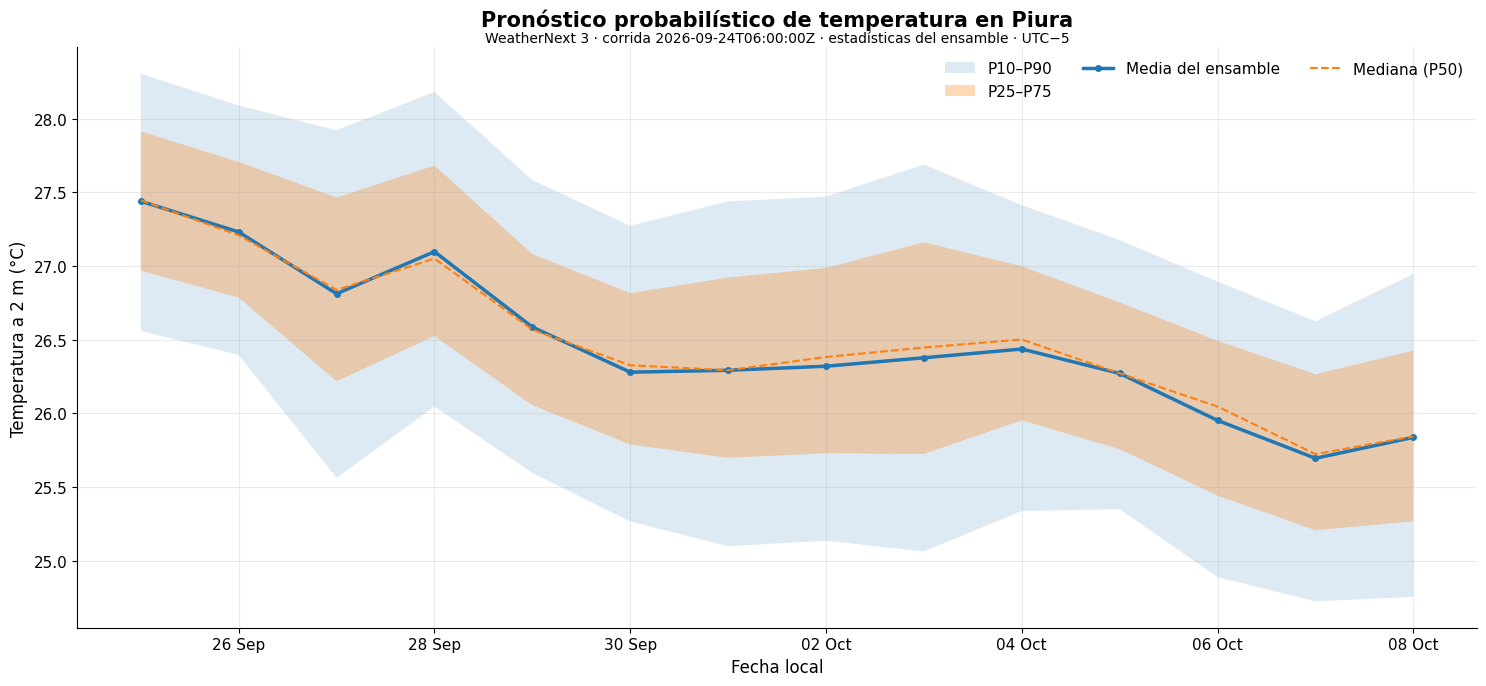

In [24]:
# ============================================================
# 23. GRÁFICA 1
# TEMPERATURA DIARIA
#
# Diseño:
#
#       P90 ────────────────
#             ╔══════════╗
#       P75   ║          ║
#             ║  P25-P75 ║
#       P25   ║          ║
#             ╚══════════╝
#       P10 ────────────────
#
# Línea azul = media del ensamble
#
# Tmin/Tmax se muestran como líneas punteadas.
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 7)
)

fechas = daily_full["fecha_local"]

# Banda P10-P90
ax.fill_between(
    fechas,
    daily_full["tmedia_p10_C"],
    daily_full["tmedia_p90_C"],
    alpha=0.15,
    label="P10–P90"
)

# Banda P25-P75
ax.fill_between(
    fechas,
    daily_full["tmedia_p25_C"],
    daily_full["tmedia_p75_C"],
    alpha=0.30,
    label="P25–P75"
)

# Media
ax.plot(
    fechas,
    daily_full["tmedia_C"],
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Media del ensamble"
)

# Mediana
ax.plot(
    fechas,
    daily_full["tmedia_p50_C"],
    linewidth=1.5,
    linestyle="--",
    label="Mediana (P50)"
)

# Tmin
#ax.plot(
#    fechas,
#   daily_full["tmin_C"],
#   linewidth=1.3,
#    label="Tmin"
#)

# Tmax
#ax.plot(
#   fechas,
 #   daily_full["tmax_C"],
#    linewidth=1.3,
#   label="Tmax"
#)

ax.set_title(
    "Pronóstico probabilístico de temperatura en Piura",
    pad=15,
    fontweight="bold"
)

ax.text(
    0.5,
    1.01,
    f"WeatherNext 3 · corrida {ultimo_start_time} · "
    "estadísticas del ensamble · UTC−5",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

ax.set_ylabel(
    "Temperatura a 2 m (°C)"
)

ax.set_xlabel(
    "Fecha local"
)

ax.xaxis.set_major_locator(
    mdates.DayLocator(interval=2)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d %b")
)

plt.xticks(rotation=0)

ax.legend(
    loc="best",
    ncol=3
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()



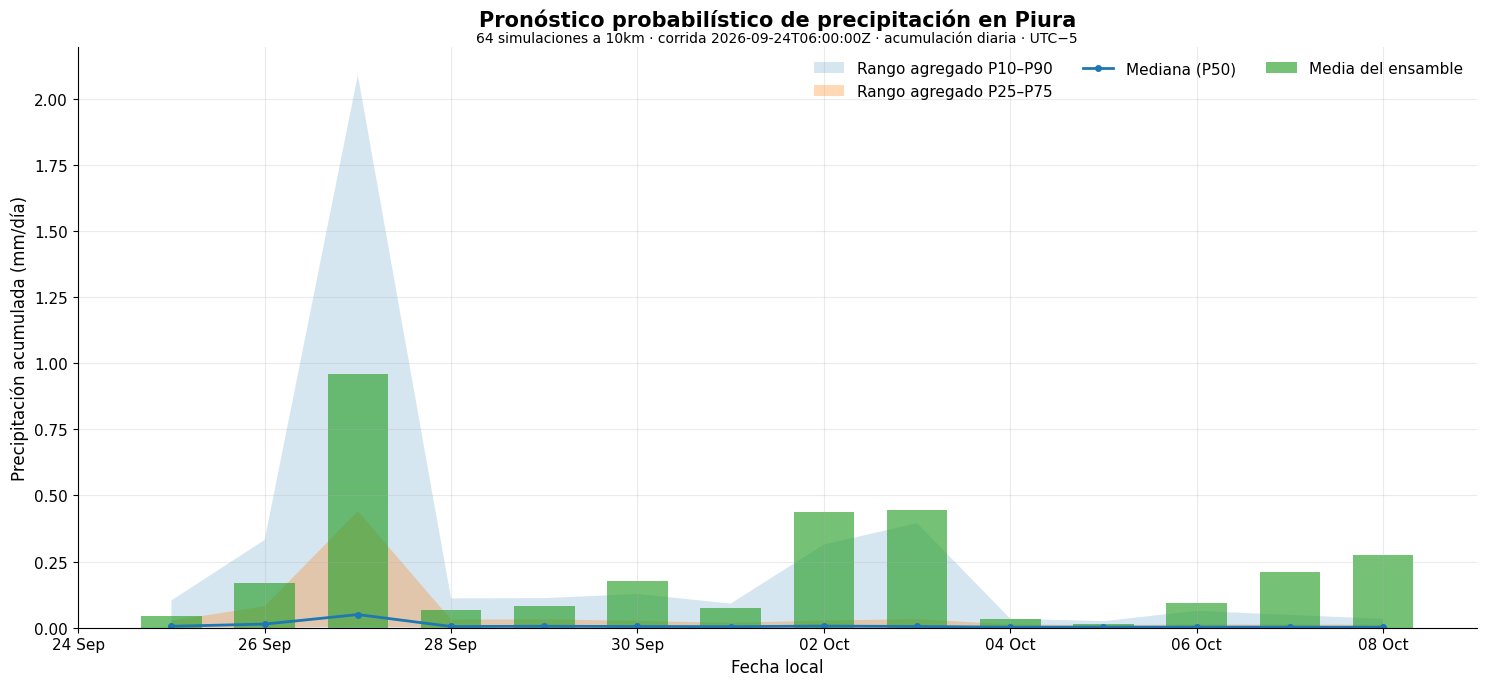

In [25]:
# ============================================================
# 24. GRÁFICA 2
# PRECIPITACIÓN DIARIA
#
# Barras = media del ensamble
#
# Línea = P50
#
# Banda = rango agregado P10-P90
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 7)
)

fechas = daily_full["fecha_local"]

# Banda de incertidumbre
ax.fill_between(
    fechas,
    daily_full["precip_p10_agregado_mm"],
    daily_full["precip_p90_agregado_mm"],
    alpha=0.18,
    label="Rango agregado P10–P90"
)

# Banda central
ax.fill_between(
    fechas,
    daily_full["precip_p25_agregado_mm"],
    daily_full["precip_p75_agregado_mm"],
    alpha=0.30,
    label="Rango agregado P25–P75"
)

# Barras de precipitación media
ax.bar(
    fechas,
    daily_full["precip_mean_mm"],
    width=0.65,
    alpha=0.65,
    label="Media del ensamble"
)

# Mediana
ax.plot(
    fechas,
    daily_full["precip_p50_mm"],
    linewidth=2,
    marker="o",
    markersize=4,
    label="Mediana (P50)"
)

ax.set_title(
    "Pronóstico probabilístico de precipitación en Piura",
    pad=15,
    fontweight="bold"
)

ax.text(
    0.5,
    1.01,
    f"64 simulaciones a 10km · corrida {ultimo_start_time} · "
    "acumulación diaria · UTC−5",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

ax.set_ylabel(
    "Precipitación acumulada (mm/día)"
)

ax.set_xlabel(
    "Fecha local"
)

ax.xaxis.set_major_locator(
    mdates.DayLocator(interval=2)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d %b")
)

plt.xticks(rotation=0)

ax.legend(
    loc="best",
    ncol=3
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()




VENTANA 1: PRÓXIMAS 24 HORAS
Desde: 2026-09-24 10:00:00-05:00
Hasta: 2026-09-25 09:00:00-05:00
Número de horas: 24

VENTANA 2: FECHA OBJETIVO 2026-09-27
Desde: 2026-09-27 00:00:00-05:00
Hasta: 2026-09-27 23:00:00-05:00
Número de horas: 24

Pronóstico horario de precipitación para Piura – próximas 24 horas
Acumulado medio : 0.03 mm
Máximo horario  : 0.01 mm/h
Hora máxima     : 24/09/2026 16:00 PET
Figura guardada : WeatherNext3_PP_horaria_proximas_24h.png


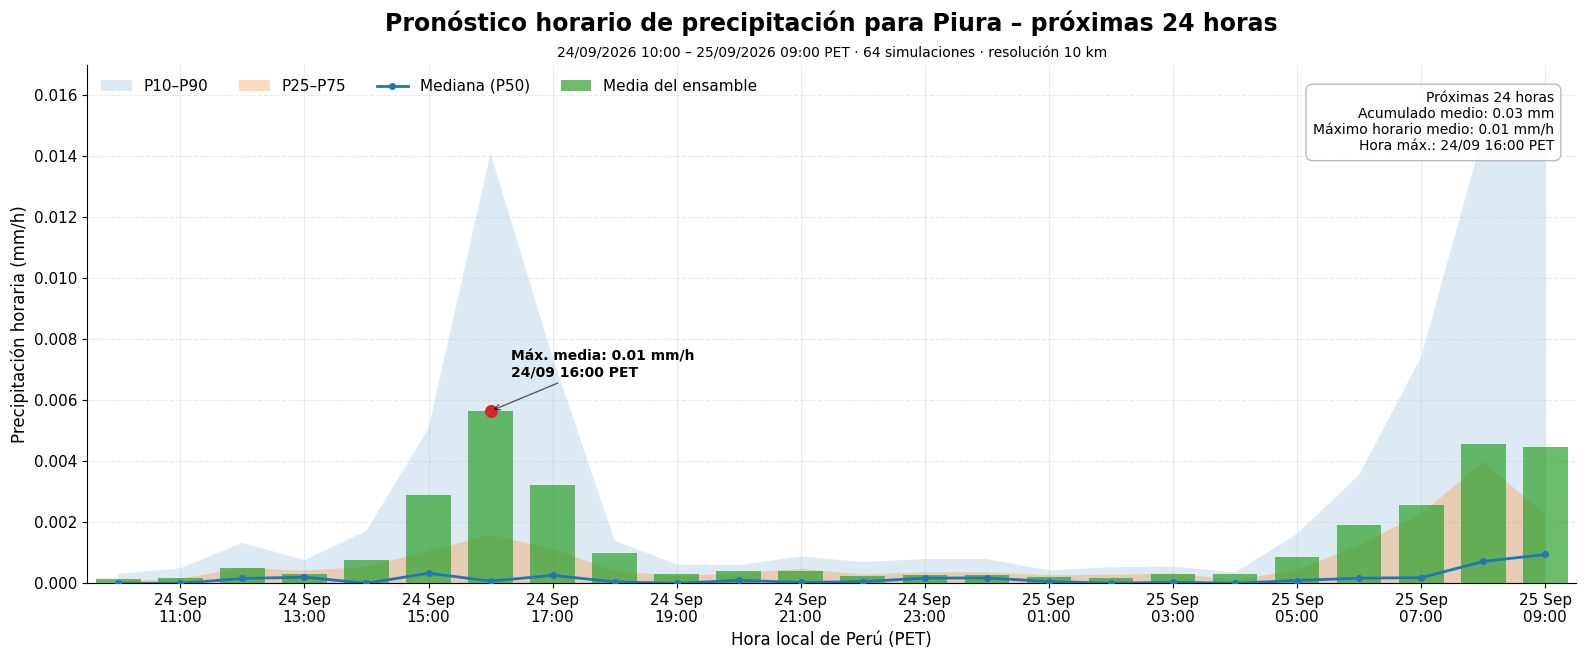


Pronóstico horario de precipitación para Piura – 27/09/2026
Acumulado medio : 0.96 mm
Máximo horario  : 0.14 mm/h
Hora máxima     : 27/09/2026 08:00 PET
Figura guardada : WeatherNext3_PP_horaria_2026-09-27.png


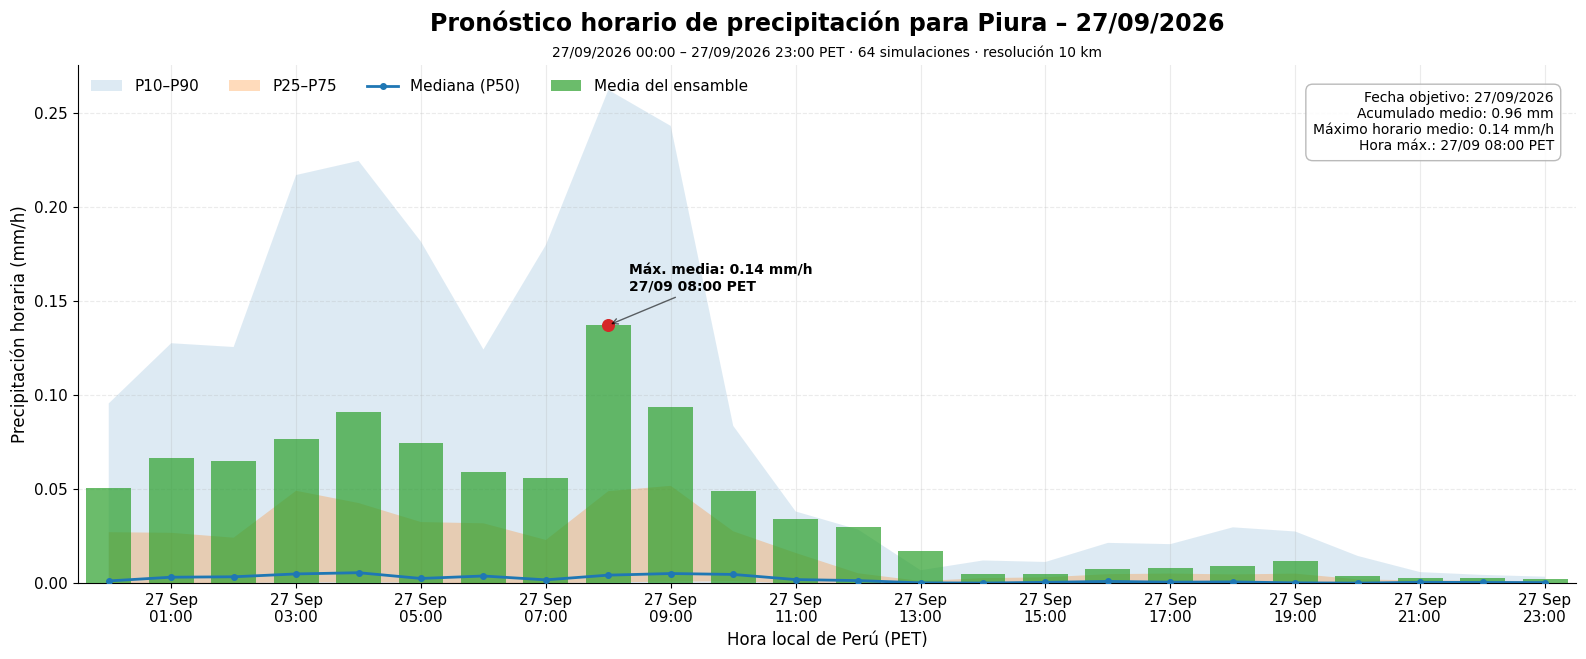


PROCESO TERMINADO
Figura 1: WeatherNext3_PP_horaria_proximas_24h.png
Figura 2: WeatherNext3_PP_horaria_2026-09-27.png


In [31]:
# ============================================================
# PRONÓSTICO HORARIO DE PRECIPITACIÓN - PIURA
#
# FIGURA 1 = PRÓXIMAS 24 HORAS
# FIGURA 2 = 24 HORAS DE UNA FECHA OBJETIVO
#
# IMPORTANTE:
# El DataFrame original debe llamarse: df
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

# ------------------------------------------------------------
# FECHA OBJETIVO
# Cambiar manualmente cuando quieras analizar otro día
# ------------------------------------------------------------

FECHA_OBJETIVO = "2026-09-27"

# Zona horaria
ZONA_HORARIA = "America/Lima"

# Nombre del lugar
LUGAR = "Piura"

# Número de simulaciones
N_SIMULACIONES = 64

# Resolución
RESOLUCION = "10 km"


# ============================================================
# 2. COPIAR DATAFRAME ORIGINAL
# ============================================================

df_h = df.copy()


# ============================================================
# 3. CONVERTIR end_time UTC -> HORA LOCAL PERÚ
# ============================================================

df_h["end_time"] = pd.to_datetime(
    df_h["end_time"],
    utc=True,
    errors="coerce"
)

df_h["fecha_local"] = (
    df_h["end_time"]
    .dt.tz_convert(ZONA_HORARIA)
)


# ============================================================
# 4. ORDENAR CRONOLÓGICAMENTE
# ============================================================

df_h = (
    df_h
    .dropna(subset=["fecha_local"])
    .sort_values("fecha_local")
    .reset_index(drop=True)
)


# ============================================================
# 5. VARIABLES DE PRECIPITACIÓN
# ============================================================

variables_pp = [
    "precip_mm_mean",
    "precip_mm_p10",
    "precip_mm_p25",
    "precip_mm_p50",
    "precip_mm_p75",
    "precip_mm_p90"
]


# ============================================================
# 6. VERIFICAR VARIABLES
# ============================================================

for var in variables_pp:

    if var not in df_h.columns:

        raise ValueError(
            f"No existe la columna '{var}' en df.\n"
            f"Columnas disponibles:\n{list(df_h.columns)}"
        )

    df_h[var] = pd.to_numeric(
        df_h[var],
        errors="coerce"
    )

    # La precipitación no puede ser negativa
    df_h[var] = (
        df_h[var]
        .clip(lower=0)
    )


# ============================================================
# 7. VENTANA 1
# PRÓXIMAS 24 HORAS
# ============================================================

ahora = pd.Timestamp.now(
    tz=ZONA_HORARIA
).floor("h")


# Primera hora completa posterior
inicio_24h = (
    ahora
    + pd.Timedelta(hours=1)
)

fin_24h = (
    inicio_24h
    + pd.Timedelta(hours=24)
)


df_24h = df_h[
    (df_h["fecha_local"] >= inicio_24h)
    &
    (df_h["fecha_local"] < fin_24h)
].copy()


# ============================================================
# 8. VENTANA 2
# FECHA OBJETIVO COMPLETA
# 00:00 - 23:00 PET
# ============================================================

fecha_objetivo = pd.Timestamp(
    FECHA_OBJETIVO,
    tz=ZONA_HORARIA
)

inicio_fecha = fecha_objetivo

fin_fecha = (
    fecha_objetivo
    + pd.Timedelta(days=1)
)


df_fecha = df_h[
    (df_h["fecha_local"] >= inicio_fecha)
    &
    (df_h["fecha_local"] < fin_fecha)
].copy()


# ============================================================
# 9. VERIFICAR VENTANAS
# ============================================================

print("\n" + "=" * 80)
print("VENTANA 1: PRÓXIMAS 24 HORAS")
print("=" * 80)

if len(df_24h) > 0:

    print(
        "Desde:",
        df_24h["fecha_local"].iloc[0]
    )

    print(
        "Hasta:",
        df_24h["fecha_local"].iloc[-1]
    )

    print(
        "Número de horas:",
        len(df_24h)
    )

else:

    print("NO HAY DATOS")


print("\n" + "=" * 80)
print(
    f"VENTANA 2: FECHA OBJETIVO "
    f"{FECHA_OBJETIVO}"
)
print("=" * 80)

if len(df_fecha) > 0:

    print(
        "Desde:",
        df_fecha["fecha_local"].iloc[0]
    )

    print(
        "Hasta:",
        df_fecha["fecha_local"].iloc[-1]
    )

    print(
        "Número de horas:",
        len(df_fecha)
    )

else:

    print("NO HAY DATOS")


# ============================================================
# 10. DETENER SI ALGUNA VENTANA ESTÁ VACÍA
# ============================================================

if len(df_24h) == 0:

    raise ValueError(
        "No existen datos para las próximas 24 horas."
    )


if len(df_fecha) == 0:

    raise ValueError(
        f"No existen datos para la fecha "
        f"{FECHA_OBJETIVO}."
    )


# ============================================================
# 11. FUNCIÓN PARA GENERAR LA GRÁFICA
# ============================================================

def graficar_precipitacion(
    datos,
    titulo,
    texto_cuadro,
    archivo
):

    # --------------------------------------------------------
    # Copiar
    # --------------------------------------------------------

    datos = datos.copy()

    datos = (
        datos
        .sort_values("fecha_local")
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # Fechas
    # --------------------------------------------------------

    fechas = datos["fecha_local"]


    # --------------------------------------------------------
    # Acumulado de la media
    # --------------------------------------------------------

    acumulado = (
        datos["precip_mm_mean"]
        .sum()
    )


    # --------------------------------------------------------
    # Máximo horario
    # --------------------------------------------------------

    idx_max = (
        datos["precip_mm_mean"]
        .idxmax()
    )

    hora_max = datos.loc[
        idx_max,
        "fecha_local"
    ]

    pp_max = datos.loc[
        idx_max,
        "precip_mm_mean"
    ]


    # ========================================================
    # CREAR FIGURA
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(16, 7)
    )


    # ========================================================
    # BANDA P10-P90
    # ========================================================

    ax.fill_between(
        fechas,
        datos["precip_mm_p10"],
        datos["precip_mm_p90"],
        alpha=0.15,
        label="P10–P90",
        zorder=1
    )


    # ========================================================
    # BANDA P25-P75
    # ========================================================

    ax.fill_between(
        fechas,
        datos["precip_mm_p25"],
        datos["precip_mm_p75"],
        alpha=0.28,
        label="P25–P75",
        zorder=2
    )


    # ========================================================
    # MEDIA DEL ENSAMBLE
    # ========================================================

    ax.bar(
        fechas,
        datos["precip_mm_mean"],
        width=0.030,
        alpha=0.70,
        label="Media del ensamble",
        zorder=3
    )


    # ========================================================
    # P50
    # ========================================================

    ax.plot(
        fechas,
        datos["precip_mm_p50"],
        linewidth=2.0,
        marker="o",
        markersize=4,
        label="Mediana (P50)",
        zorder=4
    )


    # ========================================================
    # MÁXIMO
    # ========================================================

    ax.scatter(
        hora_max,
        pp_max,
        s=70,
        zorder=6
    )


    ax.annotate(
        (
            f"Máx. media: "
            f"{pp_max:.2f} mm/h\n"
            f"{hora_max:%d/%m %H:%M} PET"
        ),

        xy=(
            hora_max,
            pp_max
        ),

        xytext=(
            15,
            25
        ),

        textcoords="offset points",

        fontsize=10,
        fontweight="bold",

        arrowprops=dict(
            arrowstyle="->",
            alpha=0.6
        ),

        zorder=7
    )


    # ========================================================
    # TÍTULO
    # ========================================================

    ax.set_title(
        titulo,
        fontsize=17,
        fontweight="bold",
        pad=25
    )


    # ========================================================
    # SUBTÍTULO
    # ========================================================

    inicio_txt = (
        fechas.iloc[0]
        .strftime("%d/%m/%Y %H:%M")
    )

    fin_txt = (
        fechas.iloc[-1]
        .strftime("%d/%m/%Y %H:%M")
    )


    ax.text(
        0.5,
        1.01,

        (
            f"{inicio_txt} – "
            f"{fin_txt} PET · "
            f"{N_SIMULACIONES} simulaciones · "
            f"resolución {RESOLUCION}"
        ),

        transform=ax.transAxes,

        ha="center",
        va="bottom",

        fontsize=10
    )


    # ========================================================
    # EJE Y
    # ========================================================

    ax.set_ylabel(
        "Precipitación horaria (mm/h)",
        fontsize=12
    )

    ax.set_ylim(
        bottom=0
    )


    # ========================================================
    # EJE X
    # ========================================================

    ax.set_xlabel(
        "Hora local de Perú (PET)",
        fontsize=12
    )


    zona = datos[
        "fecha_local"
    ].dt.tz


    ax.xaxis.set_major_locator(
        mdates.HourLocator(
            interval=2,
            tz=zona
        )
    )


    ax.xaxis.set_major_formatter(
        mdates.DateFormatter(
            "%d %b\n%H:%M",
            tz=zona
        )
    )


    # ========================================================
    # LÍMITES TEMPORALES
    # ========================================================

    ax.set_xlim(
        fechas.iloc[0]
        - pd.Timedelta(minutes=30),

        fechas.iloc[-1]
        + pd.Timedelta(minutes=30)
    )


    # ========================================================
    # CUADRÍCULA
    # ========================================================

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25,
        zorder=0
    )


    # ========================================================
    # LEYENDA
    # ========================================================

    ax.legend(
        loc="upper left",
        ncol=4,
        frameon=False
    )


    # ========================================================
    # CUADRO RESUMEN
    # ========================================================

    resumen = (
        f"{texto_cuadro}\n"
        f"Acumulado medio: "
        f"{acumulado:.2f} mm\n"
        f"Máximo horario medio: "
        f"{pp_max:.2f} mm/h\n"
        f"Hora máx.: "
        f"{hora_max:%d/%m %H:%M} PET"
    )


    ax.text(
        0.985,
        0.95,

        resumen,

        transform=ax.transAxes,

        ha="right",
        va="top",

        fontsize=10,

        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            edgecolor="0.7",
            alpha=0.90
        ),

        zorder=10
    )


    # ========================================================
    # AJUSTAR FIGURA
    # ========================================================

    fig.tight_layout(
        rect=[
            0,
            0,
            1,
            0.96
        ]
    )


    # ========================================================
    # GUARDAR
    # ========================================================

    fig.savefig(
        archivo,
        dpi=300,
        bbox_inches="tight"
    )


    # ========================================================
    # INFORMACIÓN
    # ========================================================

    print("\n" + "=" * 80)

    print(titulo)

    print(
        f"Acumulado medio : "
        f"{acumulado:.2f} mm"
    )

    print(
        f"Máximo horario  : "
        f"{pp_max:.2f} mm/h"
    )

    print(
        "Hora máxima     :",
        hora_max.strftime(
            "%d/%m/%Y %H:%M PET"
        )
    )

    print(
        "Figura guardada :",
        archivo
    )


    # ========================================================
    # MOSTRAR LA FIGURA
    # ========================================================

    plt.show()


# ============================================================
# 12. FIGURA 1
# PRÓXIMAS 24 HORAS
# ============================================================

graficar_precipitacion(

    datos=df_24h,

    titulo=(
        f"Pronóstico horario de precipitación para "
        f"{LUGAR} – próximas 24 horas"
    ),

    texto_cuadro=(
        "Próximas 24 horas"
    ),

    archivo=(
        "WeatherNext3_PP_horaria_proximas_24h.png"
    )
)


# ============================================================
# 13. PREPARAR FECHA PARA EL TÍTULO
# ============================================================

fecha_titulo = (
    pd.Timestamp(
        FECHA_OBJETIVO
    )
    .strftime("%d/%m/%Y")
)


# ============================================================
# 14. FIGURA 2
# FECHA OBJETIVO
# ============================================================

graficar_precipitacion(

    datos=df_fecha,

    titulo=(
        f"Pronóstico horario de precipitación para "
        f"{LUGAR} – {fecha_titulo}"
    ),

    texto_cuadro=(
        f"Fecha objetivo: "
        f"{fecha_titulo}"
    ),

    archivo=(
        f"WeatherNext3_PP_horaria_"
        f"{FECHA_OBJETIVO}.png"
    )
)


# ============================================================
# 15. FINAL
# ============================================================

print("\n" + "=" * 80)
print("PROCESO TERMINADO")
print("=" * 80)

print(
    "Figura 1:",
    "WeatherNext3_PP_horaria_proximas_24h.png"
)

print(
    "Figura 2:",
    f"WeatherNext3_PP_horaria_{FECHA_OBJETIVO}.png"
)